In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset using a stable, verified GitHub repository
url = "https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv"
df = pd.read_csv(url)

print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())

# 2. Check for missing values (The bane of financial datasets)
print("\n--- Missing Values per Column ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

Dataset loaded: 614 rows and 13 columns.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



--- Missing Values per Column ---
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


In [33]:
from sklearn.impute import KNNImputer

# Separate numeric and categorical features
numeric_df = df.select_dtypes(include=[np.number])
categorical_df = df.select_dtypes(exclude=[np.number])

# Initialize KNN Imputer (using the 5 mathematically closest applicants)
imputer = KNNImputer(n_neighbors=5)

# Apply the distance-based imputation to numeric columns
print("Applying KNN Imputation to numeric data...")
imputed_numeric = pd.DataFrame(imputer.fit_transform(numeric_df), columns=numeric_df.columns)

# For categorical text data (like 'Gender' or 'Married'), we fill missing blanks with the Mode (most frequent)
for col in categorical_df.columns:
    categorical_df[col] = categorical_df[col].fillna(categorical_df[col].mode()[0])

# Recombine the cleaned datasets
df_clean = pd.concat([categorical_df.reset_index(drop=True), imputed_numeric.reset_index(drop=True)], axis=1)

print(f"Missing values remaining: {df_clean.isnull().sum().max()} (Should be 0!)")

Applying KNN Imputation to numeric data...
Missing values remaining: 0 (Should be 0!)


In [34]:
from sklearn.preprocessing import LabelEncoder

# The columns that currently contain text strings
label_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

le = LabelEncoder()

# Iterate through and transform text to integers
for col in label_columns:
    # Ensure all data is string type before encoding to prevent TypeErrors
    df_clean[col] = df_clean[col].astype(str)
    df_clean[col] = le.fit_transform(df_clean[col])

print("--- Data is fully numerically encoded! ---")
display(df_clean.head())

--- Data is fully numerically encoded! ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,LP001002,1,0,0,0,0,2,1,5849.0,0.0,147.8,360.0,1.0
1,LP001003,1,1,1,0,0,0,0,4583.0,1508.0,128.0,360.0,1.0
2,LP001005,1,1,0,0,1,2,1,3000.0,0.0,66.0,360.0,1.0
3,LP001006,1,1,0,1,0,2,1,2583.0,2358.0,120.0,360.0,1.0
4,LP001008,1,0,0,0,0,2,1,6000.0,0.0,141.0,360.0,1.0


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Drop 'Loan_ID' column if it exists, as it is a non-numeric identifier
if 'Loan_ID' in df_clean.columns:
    df_clean = df_clean.drop('Loan_ID', axis=1)

# Define features (X) and target (y)
X = df_clean.drop('Loan_Status', axis=1)
y = df_clean['Loan_Status']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Initialize and train the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully!")

Training set shape: (491, 11)
Testing set shape: (123, 11)

Logistic Regression model trained successfully!


Model Accuracy: 0.8618

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


Confusion Matrix:


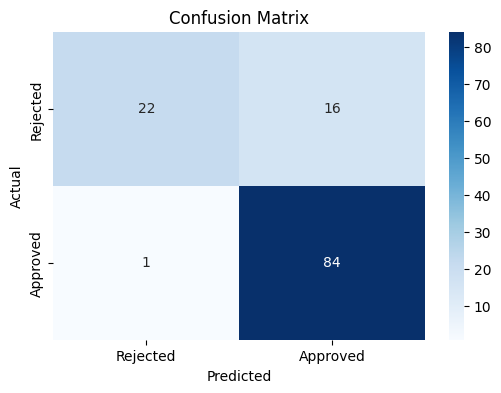

In [36]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

print("\nConfusion Matrix:")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

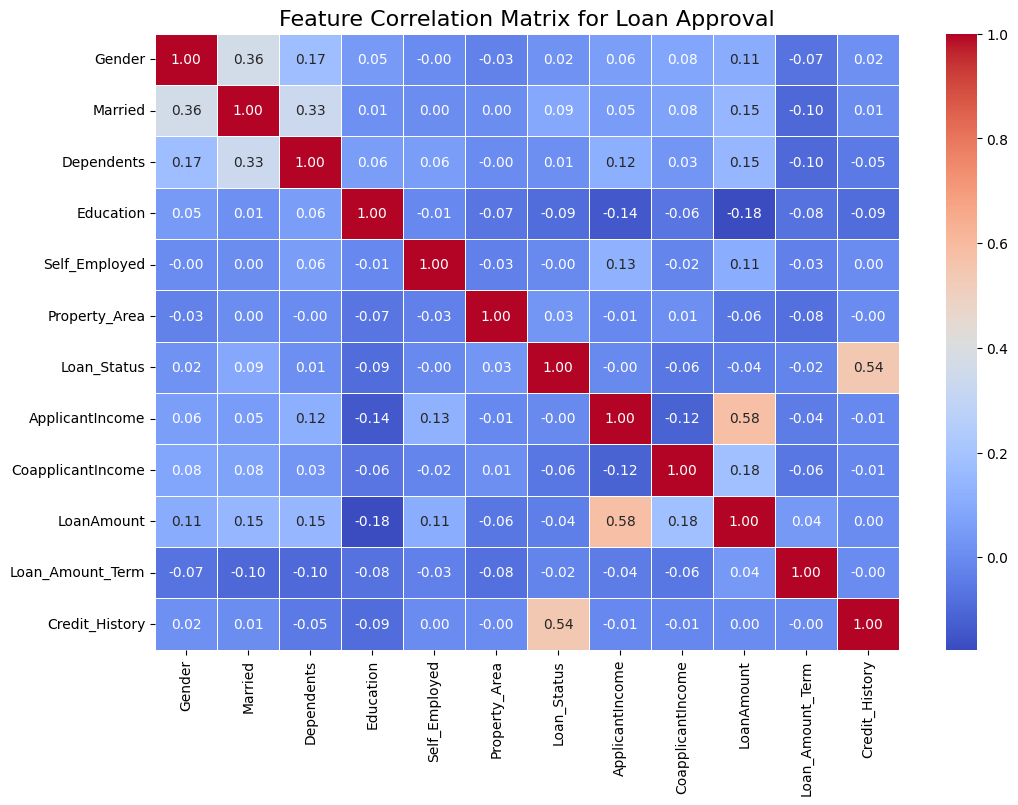


Correlation with Loan Status:
Loan_Status          1.000000
Credit_History       0.541337
Married              0.091478
Property_Area        0.032112
Gender               0.017987
Dependents           0.010118
Self_Employed       -0.003700
ApplicantIncome     -0.004710
Loan_Amount_Term    -0.021266
LoanAmount          -0.038346
CoapplicantIncome   -0.059187
Education           -0.085884
Name: Loan_Status, dtype: float64


In [37]:
# 1. Drop 'Loan_ID' if it exists, as it is just a text identifier and breaks the math
if 'Loan_ID' in df_clean.columns:
    df_clean = df_clean.drop('Loan_ID', axis=1)

# 2. Compute the correlation matrix strictly on numeric columns
plt.figure(figsize=(12, 8))
correlation_matrix = df_clean.corr(numeric_only=True)

# 3. Render the matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix for Loan Approval', fontsize=16)
plt.show()

# 4. Isolate and print the correlations specifically linked to the target
print("\nCorrelation with Loan Status:")
print(correlation_matrix['Loan_Status'].sort_values(ascending=False))

## Resources

### Loan Prediction Project

#### Project Overview
This project aimed to build a predictive model to determine whether a loan application would be approved or rejected based on various applicant features. The goal was to develop a robust binary classification model that could assist financial institutions in making informed lending decisions, thereby mitigating risk and streamlining the loan approval process.

#### Data Source
The dataset used for this project was obtained from a public GitHub repository. It contains various attributes related to loan applicants, including personal details, income information, loan amounts, and credit history.

**Source URL:** `https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv`

#### Key Steps Performed:
1.  **Data Loading**: The dataset was loaded into a Pandas DataFrame directly from the provided GitHub URL.
2.  **Missing Value Imputation**: Missing values were handled as follows:
    *   **Numeric Features**: KNN Imputer (`n_neighbors=5`) was applied to fill missing values in numeric columns such as `LoanAmount`, `Loan_Amount_Term`, `ApplicantIncome`, `CoapplicantIncome`, and `Credit_History`.
    *   **Categorical Features**: Missing values in categorical columns like `Gender`, `Married`, `Dependents`, and `Self_Employed` were imputed using the mode (most frequent value) of each respective column.
3.  **Feature Encoding**: Categorical features (e.g., `Gender`, `Married`, `Education`, `Self_Employed`, `Property_Area`, `Loan_Status`) were converted into numerical representations using `LabelEncoder` from `sklearn.preprocessing`.
4.  **Data Splitting**: The cleaned dataset was split into features (X) and the target variable (y, 'Loan_Status'). These were then further divided into training (80%) and testing (20%) sets using `train_test_split` with `random_state=42` and `stratify=y` to maintain the proportion of target classes.
5.  **Model Training**: A Logistic Regression model (`LogisticRegression(solver='liblinear', random_state=42)`) was initialized and trained on the preprocessed training data.
6.  **Model Evaluation**: The trained model's performance was evaluated on the test set using accuracy, a classification report (precision, recall, F1-score), and a confusion matrix to assess its predictive capability.
7.  **Feature Correlation Analysis**: A correlation matrix and heatmap were generated to visualize the relationships between all features, specifically highlighting the correlation of each feature with the 'Loan_Status'.

#### Models and Performance (Accuracy on Test Set):
**Model Used:** Logistic Regression

**Evaluation Metrics on Test Set:**
*   **Accuracy:** 0.8618
*   **Classification Report:**
    ```
                  precision    recall  f1-score   support

               0       0.96      0.58      0.72        38
               1       0.84      0.99      0.91        85

        accuracy                           0.86       123
       macro avg       0.90      0.78      0.81       123
    weighted avg       0.88      0.86      0.85       123
    ```
*   **Confusion Matrix Insights:**
    *   True Negatives (Correctly Predicted Rejected): 22
    *   False Positives (Incorrectly Predicted Approved): 16
    *   False Negatives (Incorrectly Predicted Rejected): 1
    *   True Positives (Correctly Predicted Approved): 84

The model demonstrates a good overall accuracy of approximately 86%. It shows high recall (0.99) for the 'Approved' class (class 1), indicating it correctly identifies most approved loans. However, the recall for the 'Rejected' class (class 0) is lower (0.58), suggesting that while it has high precision for rejections (0.96), it misses a significant portion of actual rejections. The high precision for class 0 implies that when it predicts a rejection, it's very likely correct.

#### Proposed Next Steps
1.  **Feature Engineering**: Explore creating new features from existing ones (e.g., total income, debt-to-income ratio) to potentially improve model performance.
2.  **Hyperparameter Tuning**: Optimize the Logistic Regression model's hyperparameters using techniques like GridSearchCV or RandomizedSearchCV.
3.  **Explore Advanced Models**: Experiment with more complex machine learning models such as Random Forest, Gradient Boosting, or Support Vector Machines (SVMs) to see if they yield better results.
4.  **Address Class Imbalance**: Investigate techniques to handle the class imbalance (more 'Approved' than 'Rejected' loans) to improve the model's ability to predict both classes more equally, especially the 'Rejected' class recall.
5.  **Interpretability Analysis**: Conduct further analysis to understand the most influential features driving loan approval decisions, which can provide actionable insights for financial institutions.